[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20por%20Refor%C3%A7o/Aprendizado_por_Refor%C3%A7o_M%C3%A9todos_Tabulares.ipynb)

# Inteligência Artificial e Computacional

Segunda Parte da Disciplina

Informações:

* Prof. Anderson Luiz Fernandes Perez
* Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
* Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Aprendizado por Reforço (métodos tabulares)

O **Aprendizado por Reforço** é uma área da Inteligência Artificial em que um **agente** aprende a tomar decisões por meio de interações com um **ambiente**.

A cada interação, o agente:

1. observa o estado atual;
2. escolhe uma ação;
3. executa a ação no ambiente;
4. recebe uma recompensa;
5. observa o novo estado;
6. atualiza sua estratégia de decisão.

De forma simplificada:

$
\text{Agente} \rightarrow \text{Ação} \rightarrow \text{Ambiente} \rightarrow \text{Recompensa e novo estado}
$

O objetivo é aprender uma política de ações que maximize a recompensa acumulada ao longo do tempo.

![image.png](attachment:image.png)

## Atores do Aprendizado por Reforço



### Agente

É o elemento que aprende e toma decisões. Exemplos: robô móvel, veículo autônomo, personagem de um jogo, controlador industrial ou sistema de escalonamento.

### Ambiente

É o mundo com o qual o agente interage. Exemplos: simulador de robótica, jogo, planta industrial, ambiente de navegação ou sistema embarcado.

### Estado

O estado representa a situação atual do ambiente:

$
s_t
$

Exemplos: posição do robô, velocidade, leitura de sensores, estado de carga da bateria ou posição em um mapa.

### Ação

A ação é a decisão tomada pelo agente:

$
a_t
$

Exemplos: ir para frente, virar à esquerda, acelerar, frear ou escolher uma tarefa para executar.

### Recompensa

A recompensa indica o quanto uma ação foi boa ou ruim:

$
r_t
$

Exemplos:

- +1 ao atingir o objetivo;
- -1 ao colidir;
- -0,01 a cada passo para incentivar trajetórias curtas;
- +100 ao completar uma tarefa.

### Política

A política define como o agente escolhe ações:

$
\pi(a|s)
$

Pode ser entendida como:

> dado um estado, qual ação o agente deve escolher?

## Agente-Ambiente

Em RL, o ciclo básico é:

$$
s_t \rightarrow a_t \rightarrow r_{t+1}, s_{t+1}
$$

O agente está no estado $(s_t)$, executa a ação $(a_t)$, recebe uma recompensa $(r_{t+1})$ e passa para o novo estado $(s_{t+1})$.

### Retorno acumulado

O agente deseja maximizar o retorno acumulado:

$$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots
$$

onde:

- $(G_t)$ é o retorno;
- $(\gamma)$ é o fator de desconto;
- $(0 \leq \gamma \leq 1)$.

### Interpretação de $(\gamma)$

- $(\gamma = 0)$: o agente considera apenas recompensas imediatas;
- $(\gamma \approx 1)$: o agente considera recompensas futuras com grande importância.

## Exploração versus Aproveitamento (exploration versus Exploitation)

Um dos principais dilemas em RL é:

$$
\text{exploration} \times \text{exploitation}
$$

Em português, podemos interpretar como:

- **exploração**: testar ações novas para descobrir melhores estratégias;
- **aproveitamento**: usar a melhor ação conhecida até o momento.

Uma estratégia comum é a **epsilon-greedy**:

$$
a =
\begin{cases}
\text{ação aleatória}, & \text{com probabilidade } \epsilon \\
\arg\max_a Q(s,a), & \text{com probabilidade } 1-\epsilon
\end{cases}
$$

# Exemplo de Aprendizado por Reforço em Python

## Biblioteca Gymnasium

A Gymnasium é atualmente uma das bibliotecas mais utilizadas para pesquisa e ensino de Aprendizado por Reforço (Reinforcement Learning - RL) em Python. Surgiu como sucessora da famosa biblioteca OpenAI Gym, que foi descontinuada em 2022.

Atualmente a biblioteca Gymnasium é mantida pela organização [Farama Foundation](https://farama.org/).

A biblioteca Gymnasium fornece uma interface padronizada para ambientes de RL. Ao invés de programar toda a lógica de um problema, basta carregar um ambiente pronto.

A interação com o ambiente permite:

* observar um estado;
* escolher ações;
* receber recompensas;
* receber informações sobre o término do episódio.

*Observação*: um episódio é um ciclo completo de treinamento, ou seja, o agente interage com o ambiente até atingir o objetivo ou até que uma condição de término seja atingida.

## Ambiente TAXI-V4

![image.png](attachment:image.png)

O objetivo é encontrar o passageiro, embarcá-lo no taxi e então levá-lo até o hotel.

In [ ]:
# Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import gymnasium as gym

In [ ]:
# Ambiente do taxi
env = gym.make("Taxi-v4", render_mode="ansi")

Após criar um ambiente é necessário fazer o reset para que o agente seja colocado em um ponto do ambiente e em seguida fazer a renderização. A renderização irá depender do modo com que você criou o ambiente (parâmetro "render_mode" do método "make()".

Modos de renderização (render_mode):

* ansi
* human
* rgb_array

In [ ]:
env.reset()

(62, {'prob': 1.0, 'action_mask': array([1, 0, 1, 1, 0, 0], dtype=int8)})

In [ ]:
print(env.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




### Espaço de Estados e Espaço de Ações

Os movimentos permitidos para o agente taxista são os seguintes:

* para cima (south) : 0
* para baixo (north) : 1
* para a direita (east) : 2
* para a esquerda (west) : 3
* pegar o passageiro : 4
* deixar o passageiro : 5

O espaço de observação é calculado da seguinte forma:

* o ambiente é um grid de 5 X 5 posições (25 posições)
* o passageiro pode estar em cinco localizações (ponto vermelho, amarelo, azul, verde ou dentro do taxi)

São quatro destinos para o passageiro. Logo, o espaço de observação é composto por 500 estados (5 x 5 x 5 x 4).

In [ ]:
print(f'Espaço de estados..............: {env.observation_space}')
print(f'Espalo de ações................: {env.action_space}')

Espaço de estados..............: Discrete(500)
Espalo de ações................: Discrete(6)


### Recompensas

Para que o agente receba feeedback sobre sua interação no ambiente existe um método de recompensa que pode ser negativa ou positiva.

Particularmente no problema do taxi as recompensas são as seguintes:

* -1 por andar no ambiente, ao menos que outra recompensa seja atribuída;
* +20 por deixar o passageiro no local correto;
* -10 excutar ações de pegar e deixar o passageiro de forma equivocada.

### Exemplo Ganho de Recompensa

In [ ]:
# Faz o agente ir para o sul (para baixo)
print(env.step(0))

(162, -1, False, False, {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})


In [ ]:
print(env.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)



# Processo de Treinamento do Agente

## Tabela Q (Q-Table)

A Tabela Q (Q-Table) é a estrutura de dados utilizada pelo algoritmo Q-Learning para armazenar o conhecimento adquirido pelo agente.

Funciona como uma tabela de consulta onde cada posição contém uma estimativa da qualidade de executar uma determinada ação em um determinado estado $Q(s,a)$.
$$


$$
Q =
\begin{bmatrix}
Q(s_0,a_0) & Q(s_0,a_1) & \cdots \\
Q(s_1,a_0) & Q(s_1,a_1) & \cdots \\
\vdots & \vdots & \ddots
\end{bmatrix}
$$

Quando o agente está em um estado s, ele escolhe a ação com maior valor:

$$
a = \arg\max_a Q(s,a)
$$

### Tabela Q em Python

In [ ]:
import numpy as np

n_estados = env.observation_space.n
n_acoes = env.action_space.n

q_table = np.zeros((n_estados, n_acoes))

print("Formato da Q-Table:", q_table.shape)
print(q_table)

Formato da Q-Table: (500, 6)
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


## Algoritmo Q-Learning

O **Q-Learning** aprende uma função de valor-ação:

$$
Q(s,a)
$$

Essa função estima o valor de executar a ação $(a)$ no estado $(s)$.

A atualização do Q-Learning é realizada com base na seguinte equação:

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left[r_{t+1} + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t)\right]
$$

onde:

- $(\alpha)$: taxa de aprendizado;
- $(\gamma)$: fator de desconto;
- $(r_{t+1})$: recompensa;
- $(Q(s_t,a_t))$: valor atual;
- $(\max_a Q(s_{t+1},a))$: melhor valor estimado para o próximo estado.



O Q-Learning é **off-policy**, pois atualiza a Q-Table assumindo a melhor ação futura, mesmo que a ação tomada durante a exploração seja outra.

## Treinando o Agente com o Q-Learning

In [ ]:
# Ambiente TAXI-V4
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
n_episodes = 3000
max_steps = 100

recompensas = []

for episodio in range(n_episodes):
    estado, info = env.reset()
    recompensa_total = 0

    for passo in range(max_steps):

        # Escolhe uma ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            acao = env.action_space.sample()
        else:
            acao = int(np.argmax(q_table[estado]))

        # Executa a ação
        novo_estado, recompensa, terminated, truncated, info = env.step(acao)
        fim = terminated or truncated

        melhor_q_futuro = np.max(q_table[novo_estado])

        q_table[estado, acao] = q_table[estado, acao] + alpha * (recompensa + gamma * melhor_q_futuro - q_table[estado, acao])

        estado = novo_estado
        recompensa_total += recompensa

        if fim:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas.append(recompensa_total)

print("Treinamento concluído.")
print("Q-Table gerada:")
print(q_table)

Treinamento concluído.
Q-Table gerada:
[[  0.           0.           0.           0.           0.
    0.        ]
 [  0.25098665   3.62212542   2.67511346   3.88573173   5.20997639
   -6.55126853]
 [ -4.90341866   6.6528392    5.46673269  -4.63350202  10.9512375
   -2.04161886]
 ...
 [  8.13006469  12.58025      8.10765138   9.26523152  -0.03901
   -0.710754  ]
 [ -5.69244002  -5.74870332  -5.72716524  -5.94078088 -12.98569441
  -14.08620709]
 [  9.209856    -1.8432      -1.568       17.9930112    2.97446395
   -8.        ]]


## Evolução do Aprendizado

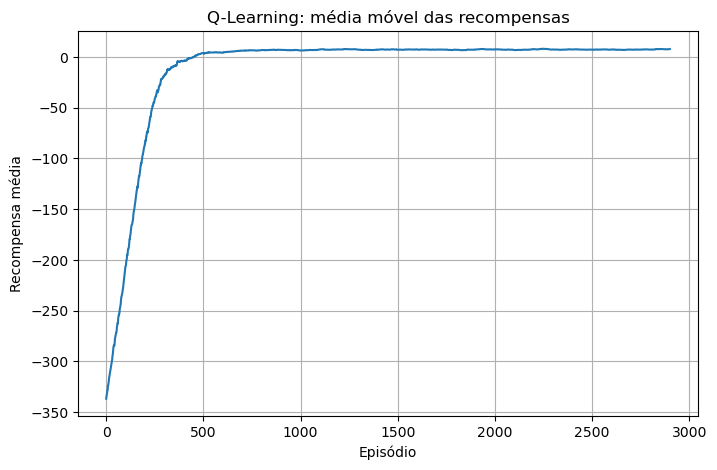

In [ ]:
def media_movel(valores, janela=100):
    return np.convolve(valores, np.ones(janela)/janela, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas, janela=100))
plt.title("Q-Learning: média móvel das recompensas")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.grid(True)
plt.show()

## Testando a Política Aprendida

In [ ]:
env = gym.make("Taxi-v4", render_mode="ansi")

estado, info = env.reset()

print(env.render())

for passo in range(20):
    acao = int(np.argmax(q_table[estado]))
    estado, recompensa, terminated, truncated, info = env.step(acao)
    fim = terminated or truncated

    print(f"Passo {passo+1} | Ação: {acao} | Recompensa: {recompensa}")
    print(env.render())

    if fim:
        break

## Algoritmo SARSA

O nome SARSA vem da sequência:

$$
S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}
$$

Ou seja:

- estado atual;
- ação atual;
- recompensa;
- próximo estado;
- próxima ação.

### Equação de atualização do SARSA

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) +
\alpha \left[
r_{t+1} + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t)
\right]
$$

O SARSA é **on-policy**, pois atualiza a Q-Table usando a próxima ação realmente escolhida pela política atual.

### Diferença entre Q-Learning e SARSA

A diferença central está no alvo da atualização.

### Q-Learning

$$
r + \gamma \max_a Q(s',a)
$$

Ele olha para a melhor ação possível no próximo estado.

### SARSA

$$
r + \gamma Q(s',a')
$$

Ele olha para a próxima ação realmente escolhida pela política.

### Considerações

- Q-Learning tende a ser mais otimista;
- SARSA tende a ser mais conservador;
- SARSA considera os efeitos da política exploratória;
- Q-Learning aprende uma política ótima independentemente da política exploratória, sob certas condições.

## Treinando o Agente com o SARSA

In [ ]:
n_states = env.observation_space.n
n_actions = env.action_space.n

q_table_sarsa = np.zeros((n_estados, n_acoes))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
n_episodes = 3000
max_steps = 100

recompensas_sarsa = []

for episodio in range(n_episodes):
    estado, info = env.reset()
    recompensa_total = 0

    for passo in range(max_steps):

        # Escolhe uma ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            acao = env.action_space.sample()
        else:
            acao = int(np.argmax(q_table[estado]))

        novo_estado, recompensa, terminated, truncated, info = env.step(acao)
        fim = terminated or truncated

        # Escolhe uma nova ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            nova_acao = env.action_space.sample()
        else:
            nova_acao = int(np.argmax(q_table[estado]))

        q_table_sarsa[estado, acao] = q_table_sarsa[estado, acao] + alpha * (
            recompensa + gamma * q_table_sarsa[novo_estado, nova_acao] - q_table_sarsa[estado, acao]
        )

        estado = novo_estado
        acao = nova_acao
        recompensa_total += recompensa

        if fim:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas_sarsa.append(recompensa_total)

print("Treinamento SARSA concluído.")
print("Q-Table SARSA gerada:")
print(q_table_sarsa)

Treinamento SARSA concluído.
Q-Table SARSA gerada:
[[  0.           0.           0.           0.           0.
    0.        ]
 [-15.29792885 -20.18272048  -1.00255711  -1.1136     -24.78549946
  -29.4666314 ]
 [-12.68457398   0.         -10.28155348 -22.85847423 -24.17683008
  -32.74283826]
 ...
 [  8.25505951  10.95122938   8.31383894  -7.62070165  -4.05448199
  -12.91152283]
 [-15.69993669  -6.94047097  -4.17899117 -11.58196358 -12.05852451
  -14.21816824]
 [  5.59223345 -16.13749658 -18.58703057  15.78377604 -28.10698223
  -16.7072768 ]]


# Comparando Q-Learning e SARSA

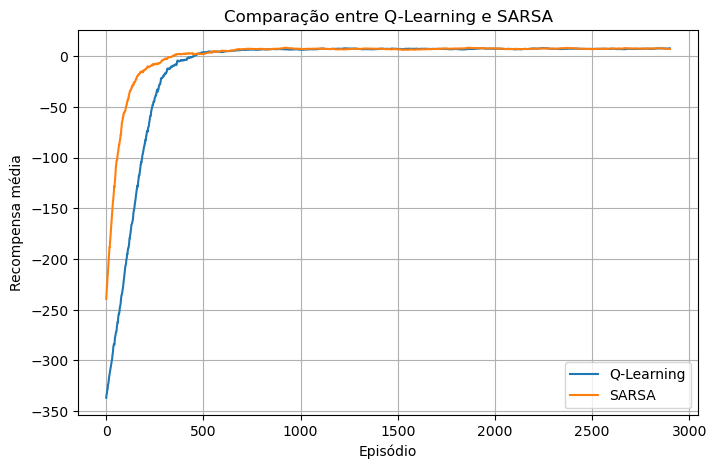

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas, janela=100), label="Q-Learning")
plt.plot(media_movel(recompensas_sarsa, janela=100), label="SARSA")
plt.title("Comparação entre Q-Learning e SARSA")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.legend()
plt.grid(True)
plt.show()

Caminhada em penhascos

## Q-Learning para o Ambiente CliffWalking-v0

In [27]:
n_states_cliff = env.observation_space.n
n_actions_cliff = env.action_space.n
q_table_cliff = np.zeros((n_states_cliff, n_actions_cliff))

print("Formato da Q-Table para Caminhada no Penhasco:", q_table_cliff.shape)
print(q_table_cliff)

Formato da Q-Table para Caminhada no Penhasco: (48, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Treinando o Agente com Q-Learning Caminhada no penhasco

In [26]:
alpha_cliff = 0.8
gamma_cliff = 0.95
epsilon_cliff = 1.0
epsilon_min_cliff = 0.01
epsilon_decay_cliff = 0.995
n_episodes_cliff = 3000
max_steps_cliff = 100

recompensas_cliff = []

# Re-initialize epsilon for a fresh training run
epsilon = epsilon_cliff

for episodio in range(n_episodes_cliff):
    estado_cliff, info_cliff = env.reset()
    recompensa_total_cliff = 0

    for passo in range(max_steps_cliff):
        if np.random.random() < epsilon:
            acao_cliff = env.action_space.sample()
        else:
            acao_cliff = int(np.argmax(q_table_cliff[estado_cliff]))

        novo_estado_cliff, recompensa_cliff, terminated_cliff, truncated_cliff, info_cliff = env.step(acao_cliff)
        fim_cliff = terminated_cliff or truncated_cliff

        melhor_q_futuro_cliff = np.max(q_table_cliff[novo_estado_cliff])

        q_table_cliff[estado_cliff, acao_cliff] = q_table_cliff[estado_cliff, acao_cliff] + alpha_cliff * (
            recompensa_cliff + gamma_cliff * melhor_q_futuro_cliff - q_table_cliff[estado_cliff, acao_cliff]
        )

        estado_cliff = novo_estado_cliff
        recompensa_total_cliff += recompensa_cliff

        if fim_cliff:
            break

    epsilon = max(epsilon_min_cliff, epsilon * epsilon_decay_cliff)
    recompensas_cliff.append(recompensa_total_cliff)

print("Treinamento Q-Learning para Caminhada no Penhasco concluído.")
print("Q-Table gerada para Caminhada no penhasco:")
print(q_table_cliff)

Treinamento Q-Learning para Caminhada no Penhasco concluído.
Q-Table gerada para Caminhada no penhasco:
[[ -10.7341754   -10.24650042  -10.24650042  -10.7341754 ]
 [ -10.24650042   -9.73315833   -9.73315833  -10.7341754 ]
 [  -9.73315833   -9.19279825   -9.19279825  -10.24650042]
 [  -9.19279825   -8.62399815   -8.62399815   -9.73315833]
 [  -8.62399815   -8.02526122   -8.02526122   -9.19279825]
 [  -8.02526122   -7.39501181   -7.39501181   -8.62399815]
 [  -7.39501181   -6.73159137   -6.73159137   -8.02526122]
 [  -6.73159137   -6.03325408   -6.03325408   -7.39501181]
 [  -6.03325408   -5.29816219   -5.29816219   -6.73159137]
 [  -5.29816219   -4.52438125   -4.52438125   -6.03325408]
 [  -4.52438125   -3.709875     -3.709875     -5.29816219]
 [  -3.709875     -3.709875     -2.8525       -4.52438125]
 [ -10.7341754    -9.73315833   -9.73315833  -10.24650042]
 [ -10.24650042   -9.19279825   -9.19279825  -10.24650042]
 [  -9.73315833   -8.62399815   -8.62399815   -9.73315833]
 [  -9.1927

Visualização grafica(Evolução do treinamento)

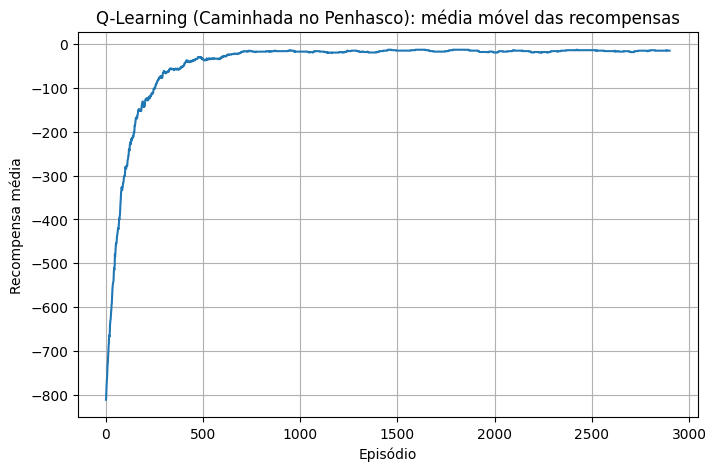

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas_cliff, janela=100))
plt.title("Q-Learning (Caminhada no Penhasco): média móvel das recompensas")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.grid(True)
plt.show()

Testando(Caminhada no penhasco)

In [23]:
env_test_cliff = gym.make("CliffWalking-v1", render_mode="ansi")

estado_test_cliff, info_test_cliff = env_test_cliff.reset()

print(env_test_cliff.render())

for passo in range(20):
    acao_test_cliff = int(np.argmax(q_table_cliff[estado_test_cliff]))
    estado_test_cliff, recompensa_test_cliff, terminated_test_cliff, truncated_test_cliff, info_test_cliff = env_test_cliff.step(acao_test_cliff)
    fim_test_cliff = terminated_test_cliff or truncated_test_cliff

    print(f"Passo {passo+1} | Ação: {acao_test_cliff} | Recompensa: {recompensa_test_cliff}")
    print(env_test_cliff.render())

    if fim_test_cliff:
        break

env_test_cliff.close()

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Passo 1 | Ação: 0 | Recompensa: -1
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


Passo 2 | Ação: 1 | Recompensa: -1
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  x  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


Passo 3 | Ação: 1 | Recompensa: -1
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  x  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


Passo 4 | Ação: 1 | Recompensa: -1
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  x  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


Passo 5 | Ação: 1 | Recompensa: -1
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  x  o  o  o  o  o  o  o
o  C  C  C

# Referências

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.